# ניתוח PCA של ספקטרום בעזרת SciPy

במחברת זו ניצור נתונים שמזכירים מדידות ספקטרוסקופיות של תערובות. כל דוגמה תאופיין באמצעות ספקטרום שלם, כלומר הרבה נקודות בליעה באורכי גל שונים. לאחר מכן נשתמש באלגוריתם הנקרא principle component analysis (PCA) כדי להציג את ההתפלגות הדוגמאות בגרף דו־ממדי.

המטרה היא להבין איך אפשר לראות מבנה בנתונים עם הרבה עמודות.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd

## יצירת ספקטרומים של חומרים טהורים

ניצור שלושה חומרים דמיוניים. לכל חומר יש ספקטרום בליעה עם פס אחד או שניים. נשתמש בפונקציה גאוסיאנית כדי לקבל פס חלק.

נשתמש כאן שוב ב־`np.exp` כדי לבנות פונקציה גאוסיאנית: הערך גדול ליד מרכז הפס, ודועך ככל שמתרחקים ממנו.


In [8]:
def gaussian(x, center, width, height):
    return height * np.exp(-(x - center)**2 / (2 * width**2))

wavelength = np.linspace(400, 700, 301) # nm

spectrum_A = gaussian(wavelength, 470, 18, 1.0) + gaussian(wavelength, 610, 35, 0.25)
spectrum_B = gaussian(wavelength, 535, 24, 0.9)
spectrum_C = gaussian(wavelength, 650, 20, 0.8) + gaussian(wavelength, 430, 30, 0.35)

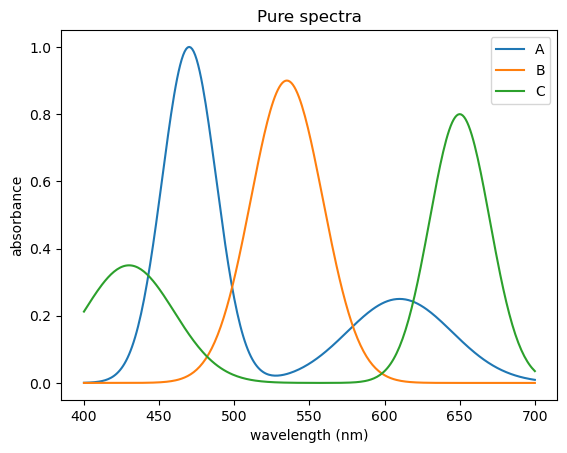

In [9]:
fig, ax = plt.subplots()
ax.plot(wavelength, spectrum_A, label='A')
ax.plot(wavelength, spectrum_B, label='B')
ax.plot(wavelength, spectrum_C, label='C')
ax.set_xlabel('wavelength (nm)')
ax.set_ylabel('absorbance')
ax.set_title('Pure spectra')
ax.legend()
plt.show()

## יצירת תערובות

כעת ניצור הרבה דוגמאות. כל דוגמה תהיה תערובת של שלושת החומרים הטהורים, ונדמה גם קצת רעש מדידה. אם $x_A$, $x_B$, ו־$x_C$ הם מקדמי התערובת, אז הספקטרום הוא:

$$S_\mathrm{mix}(\lambda) = x_A S_A(\lambda) + x_B S_B(\lambda) + x_C S_C(\lambda) + \mathrm{noise}$$

בקוד הבא `rng.dirichlet` משמשת רק כדי ליצור דוגמאות מלאכותיות של תערובות: בכל שורה נקבל שלושה מספרים חיוביים שסכומם 1, ולכן אפשר לפרש אותם כשברים של החומרים A, B ו־C. אין צורך להבין כאן את ההתפלגות עצמה; היא רק דרך נוחה לבנות נתוני דוגמה.


In [45]:
rng = np.random.default_rng(123)

n_samples = 800
fractions = rng.dirichlet([1.2, 1.2, 1.2], size=n_samples)
pure_spectra = np.vstack([spectrum_A, spectrum_B, spectrum_C])

# כל שורה היא דוגמה, וכל עמודה היא אורך גל
data = fractions @ pure_spectra
data += rng.normal(0.0, 0.05, size=data.shape)

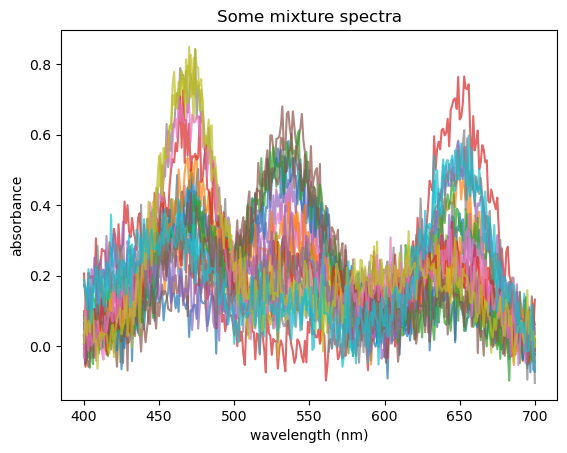

In [48]:
fig, ax = plt.subplots()
for i in range(20):
    ax.plot(wavelength, data[i], alpha=0.7)

ax.set_xlabel('wavelength (nm)')
ax.set_ylabel('absorbance')
ax.set_title('Some mixture spectra')
plt.show()

כל ספקטרום הוא וקטור עם 301 ערכים. קשה להשוות מאות דוגמאות כאלה בעין. PCA מנסה למצוא צירים חדשים שמסכמים את רוב השונות בנתונים.

## הכנה ל־PCA

לפני PCA מחסרים מכל עמודה את הממוצע שלה. כך אנחנו מנתחים את ההבדלים בין הדוגמאות, ולא את הספקטרום הממוצע עצמו.

In [49]:
mean_spectrum = np.mean(data, axis=0)
centered_data = data - mean_spectrum

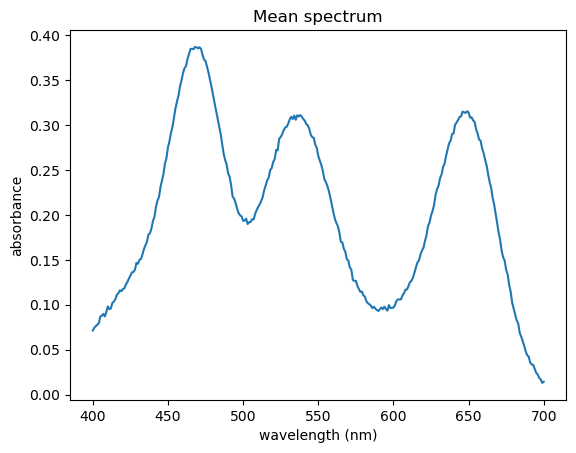

In [50]:
fig, ax = plt.subplots()
ax.plot(wavelength, mean_spectrum)
ax.set_xlabel('wavelength (nm)')
ax.set_ylabel('absorbance')
ax.set_title('Mean spectrum')
plt.show()

## חישוב PCA בעזרת SVD

נשתמש ב־`scipy.linalg.svd`. פונקציה זו מבצעת פירוק של מטריצה לערכים סינגולריים. זו הכללה של פעולת הליכסון, והיא שימושית כדי למצוא רכיבים "חשובים" בנתונים. במקרה של מטריצה ריבועית וניתנת לליכסון, הרכיבים החשובים יהיו פשוט ווקטורים עצמיים עם ערכים עצמיים גדולים במיוחד. עם זאת, ה־svd מכליל את הרעיון למטריצות כלליות. 

השימוש שלנו יהיה פשוט למדי: שני הרכיבים הראשונים יגדירו את שני המימדים שבהם הנתונים הכי משתנים, ולכן יתנו לנו דרך לצייר גרף דו־ממדי המאפיין הדוגמאות.

In [51]:
U, s, Vt = svd(centered_data, full_matrices=False)

scores = U[:, :2] * s[:2]
explained_variance = s**2 / np.sum(s**2)

print(f'PC1 explains {100 * explained_variance[0]:.1f}% of the variance')
print(f'PC2 explains {100 * explained_variance[1]:.1f}% of the variance')

PC1 explains 53.3% of the variance
PC2 explains 30.1% of the variance


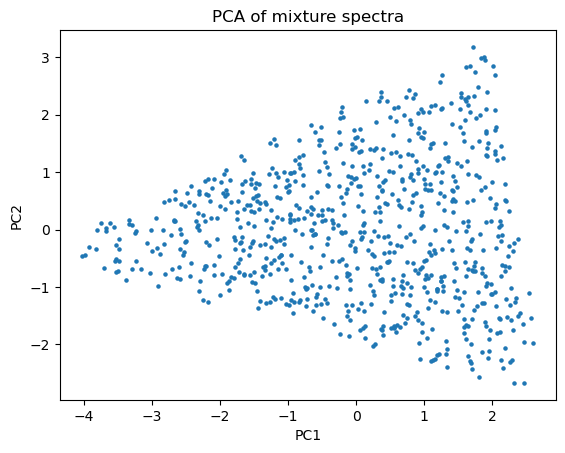

In [52]:
fig, ax = plt.subplots()
ax.scatter(scores[:, 0], scores[:, 1],s=5)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('PCA of mixture spectra')
plt.show()

הנקודות בגרף הן הדוגמאות המקוריות. כל דוגמה הייתה ספקטרום עם 301 נקודות, ועכשיו היא מיוצגת על־ידי שני מספרים בלבד. אם יש מבנה בתערובות, למשל דוגמאות עשירות בחומר מסוים, לעיתים אפשר לראות אותו בגרף הזה.

## צביעה לפי הרכב התערובת

בנתונים ניסיוניים אמיתיים בדרך כלל לא נדע את ההרכב המדויק. כאן, מפני שאנחנו יצרנו את הנתונים בעצמנו, אפשר לצבוע את הנקודות לפי כמות אחד החומרים ולראות מה PCA גילתה.

כדי להשוות בין שלושת החומרים באותו מבט, נשתמש ב־`plt.subplots` וניצור שלושה צירים (`axes`) באותה שורה. כל ציר יהיה פאנל אחד בגרף.

המערך `fractions` בנוי כך שכל שורה היא דוגמה, ושלוש העמודות הן השברים של A, B ו־C. כדי לעבור חומר־חומר נשתמש ב־`fractions.T`, כלומר בשחלוף של המערך: אחרי השחלוף כל שורה מתאימה לחומר אחד. פעולה זו הופיעה כבר בשבוע 7, וכאן היא רק עוזרת לנו לקחת את שלוש סדרות הצבעים לפי הסדר A, B, C.


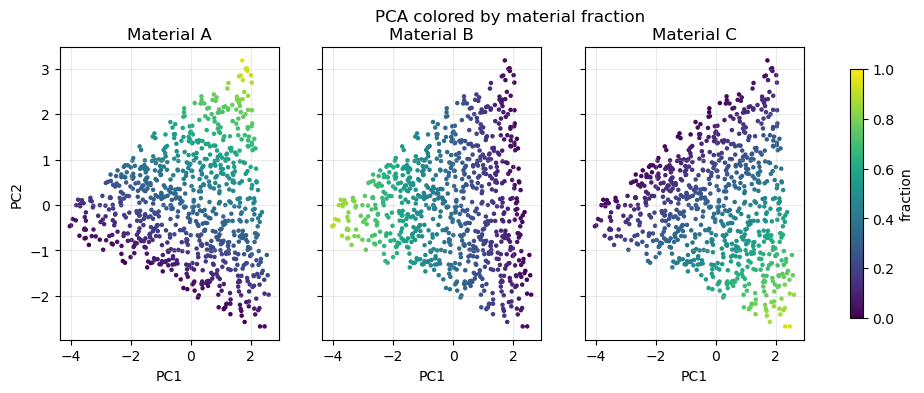

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharex=True, sharey=True)
materials = ['A', 'B', 'C']
fractions_by_material = fractions.T

for i in range(3):
    ax = axes[i]
    material = materials[i]
    fraction = fractions_by_material[i]

    scatter = ax.scatter(scores[:, 0], scores[:, 1], c=fraction, vmin=0, vmax=1, s=5)
    ax.set_title(f'Material {material}')
    ax.set_xlabel('PC1')
    ax.grid(alpha=0.25)

axes[0].set_ylabel('PC2')
fig.suptitle('PCA colored by material fraction')
fig.colorbar(scatter, ax=axes, label='fraction', shrink=0.85)
plt.show()

הצבעים מראים שהצירים שקיבלנו מתהליך ה־PCA קשורים להרכב הכימי של התערובות, אף על פי שהחישוב עצמו קיבל רק את הספקטרומים ולא את ההרכבים.